导师任务：

要去Chicago data portal 找business Licenses data 然后
parcel Only focus on commercial
Link Chicago business licenses 

1. Get the new and old business licenses — Match with the Chicago parcel data 
2.  match Old business liscences, new business licenses, parcels, this business was at this id 
Assign id, one is year and one is location id 根据地理位置match两个dataset
Create one dataset
Save as parquet

chicago government data
get the chicago business registry data - chicago business licenses https://data.cityofchicago.org/Community-Economic-Development/Business-Licenses-Current-Active/uupf-x98q/about_data: historical and active
finish getting the chicago parcels — get the additionald atas 
match based on year and lat lon 
save as: .parquet

# Dataset Preview



Business Licence(ALL): https://data.cityofchicago.org/Community-Economic-Development/Business-Licenses/r5kz-chrr/about_data

- Business License OData: https://data.cityofchicago.org/api/odata/v4/r5kz-chrr?$format=json
    
    (- Currnet Active: https://data.cityofchicago.org/Community-Economic-Development/Business-Licenses-Current-Active/uupf-x98q/about_data  )

    (- Historic: https://data.cityofchicago.org/Community-Economic-Development/Business-License-History-Snapshot/r3b4-wv66/about_data  )

Chicago Boundary(GeoData): https://drive.google.com/drive/folders/1JnzBO3kRZx88PXotE7Lj0sfB7yM7_v6Y?usp=drive_link

**Dataset**———— Assessor - Assessed Values （OData）
https://datacatalog.cookcountyil.gov/api/odata/v4/uzyt-m557?$format=json

- Assessor - Commercial Valuation Data: https://datacatalog.cookcountyil.gov/Property-Taxation/Assessor-Commercial-Valuation-Data/csik-bsws/about_data

## 1-1 Parcels

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

# Read the shapefile from the Parcels/Parcel_2016 folder
shapefile_path = Path("Parcels") / "Parcel_2016" / "Parcels.shp"
parcels = gpd.read_file(shapefile_path)

print("Rows:", len(parcels))
print("Columns:", len(parcels.columns))
print("CRS:", parcels.crs)

parcels.head()

Rows: 1429015
Columns: 18
CRS: EPSG:3435


,OBJECTID,Name,PIN10,PINA,PINSA,PINB,PINP,PINU,PINAC,TAXCODE,JOB_NO,UPPER_ELEV,LOWER_ELEV,SURVEY_CAL,PARCELTYPE,SHAPE_STAr,SHAPE_STLe,geometry
0,1,14169990010000,1416999001,14,16,999,1,0,0.0,0,0,0.0,0.0,0.0,1,6.239358e+06,34936.918738,"POLYGON ((1171770.54 1932127.24, 1171775.14 19..."
1,2,26059990010000,2605999001,26,5,999,1,0,0.0,0,0,0.0,0.0,0.0,1,2.662026e+06,14026.678236,"POLYGON ((1204316.239 1846161.82, 1204325.269 ..."
2,3,NaN,1703233001,17,3,233,1,0,0.0,0,2006003137,0.0,0.0,0.0,6,2.952335e+05,3687.873180,"POLYGON ((1178340.29 1907573.35, 1178463.66 19..."
3,4,02354070080000,0235407008,2,35,407,8,0,0.0,0,0,0.0,0.0,0.0,1,6.104053e+02,120.775098,"POLYGON ((1066211.592 1967061.809, 1066190.888..."
4,5,02353060210000,0235306021,2,35,306,21,0,0.0,0,0,0.0,0.0,0.0,1,3.956096e+03,349.964211,"POLYGON ((1064304.716 1967074.867, 1064156.574..."


In [ ]:
# Show geometry type distribution and quick bounds check
print(parcels.geometry.geom_type.value_counts(dropna=False).head())
print("Total bounds [minx, miny, maxx, maxy]:", parcels.total_bounds)

Polygon         1428853
MultiPolygon        162
Name: count, dtype: int64
Total bounds [minx, miny, maxx, maxy]: [1003175.74806125 1749884.65216199 1205633.62201608 1998851.70507991]


In [ ]:
# Check PARCELTYPE distribution — this tells us how parcels are categorized
print("=== PARCELTYPE value counts ===")
print(parcels["PARCELTYPE"].value_counts().sort_index())

print("\n=== TAXCODE sample (first 20 unique) ===")
print(sorted(parcels["TAXCODE"].unique())[:20])

print("\n=== Columns with non-null rate ===")
print(parcels.notnull().mean().round(2))

=== PARCELTYPE value counts ===
PARCELTYPE
0       4598
1    1402736
2       1165
3      19216
4          1
5        464
6        814
7          5
9         16
Name: count, dtype: int64

=== TAXCODE sample (first 20 unique) ===
[0]

=== Columns with non-null rate ===
OBJECTID      1.0
Name          1.0
PIN10         1.0
PINA          1.0
PINSA         1.0
PINB          1.0
PINP          1.0
PINU          1.0
PINAC         1.0
TAXCODE       1.0
JOB_NO        1.0
UPPER_ELEV    1.0
LOWER_ELEV    1.0
SURVEY_CAL    1.0
PARCELTYPE    1.0
SHAPE_STAr    1.0
SHAPE_STLe    1.0
geometry      1.0
dtype: float64


In [ ]:
import os

# List all files in the current folder
print("=== Files in folder ===")
for f in sorted(os.listdir(".")):
    size_kb = os.path.getsize(f) / 1024
    print(f"  {f:40s}  {size_kb:10.1f} KB")

# Show ALL unique values across every column to find commercial hints
print("\n=== Unique value counts per column ===")
for col in parcels.columns:
    if col == "geometry":
        continue
    n_unique = parcels[col].nunique()
    print(f"  {col:15s}: {n_unique} unique values", end="")
    if n_unique <= 20:
        print(f"  → {sorted(parcels[col].dropna().unique())}")
    else:
        print()

=== Files in folder ===
  .venv                                            4.0 KB
  Parcels.cpg                                      0.0 KB
  Parcels.dbf                                 284687.1 KB
  Parcels.prj                                      0.5 KB
  Parcels.sbn                                  11775.2 KB
  Parcels.sbx                                    179.0 KB
  Parcels.shp                                 294983.1 KB
  Parcels.shp.xml                                794.6 KB
  Parcels.shx                                  11164.3 KB
  test.ipynb                                      11.1 KB

=== Unique value counts per column ===
  OBJECTID       : 1429015 unique values
  Name           : 1414529 unique values
  PIN10          : 1414506 unique values
  PINA           : 34 unique values
  PINSA          : 37 unique values
  PINB           : 286 unique values
  PINP           : 570 unique values
  PINU           : 42 unique values
  PINAC          : 4289 unique values
  TAXCODE    

### 字符段含义



**关于预览表格里的字段含义：**

| 字段 | 含义 |
|------|------|
| `OBJECTID` | 系统内部行号 |
| `Name` / `PIN10` | **地块唯一编号（PIN）**，这是以后连接其他数据的主键 |
| `PINA/PINSA/PINB/PINP/PINU` | PIN 的各个分段（township/district/block等），拆开存的 |
| `TAXCODE` | 税区代码（这份数据里全是 0，没用） |
| `PARCELTYPE` | 地块类型代码（见下方） |
| `SHAPE_STAr` | 地块面积 |
| `SHAPE_STLe` | 地块周长 |
| `geometry` | 地块的多边形坐标 |

**关键问题：`PARCELTYPE` 不是"商业/住宅"的区分**

`PARCELTYPE` 是测量类型（1=普通地块，2=公寓，3=免税用地等），**这份 shapefile 里没有直接的商业用途字段**。要筛选商业地块，需要额外从 [Cook County Assessor](https://datacatalog.cookcountyil.gov/) 下载 property class 数据（里面有 5-xxx 开头的代码表示商业），然后用 PIN10 去 join。

---

**关于你理解的流程——基本对，但要补一步：**

你理解的：
> CSV (business licenses) → 筛选有用信息 → 合并到 parcel 地图 → 存 parquet

更准确的步骤是：

```
① 下载 Business Licenses CSV（Chicago Data Portal）
② 读取 Parcels.shp（已有）
③ [可选] 筛选 commercial parcel：
      从 Cook County Assessor 下载 property class，
      用 PIN10 join 到 parcel，保留 class 5-xxx 的地块
④ 空间匹配（spatial join）：
      把 business license 的经纬度（lat/lon）点
      对应到 parcel 多边形 → 得到每条执照属于哪个地块（PIN10）
⑤ 加上年份字段（从执照的发证日期提取 year）
⑥ 合并成一张表，保存为 .parquet
```




| 字段名 | 含义（可用解释） | 备注 |
|---|---|---|
| OBJECTID | 记录唯一行号（系统生成） | 常用作内部索引，不是业务主键 |
| Name | Parcel 标识字符串（看起来是更长位数的 PIN 形式） | 与 PIN10 同源，常作为完整地块编号文本 |
| PIN10 | 10 位 Parcel Identification Number（地块主编号） | 最重要的连接键之一 |
| PINA | PIN 的分段 A | PIN 的行政/地籍分段 |
| PINSA | PIN 的分段 SA | PIN 的行政/地籍分段 |
| PINB | PIN 的分段 B | PIN 的行政/地籍分段 |
| PINP | PIN 的分段 P | PIN 的行政/地籍分段 |
| PINU | PIN 的分段 U | PIN 的行政/地籍分段 |
| PINAC | PIN 的扩展/附加编码（数值型） | 具体编码规则需源数据字典确认 |
| TAXCODE | 税务代码 | 你这份数据里当前几乎全是 0，可用性有限 |
| JOB_NO | 作业/批处理编号（数据维护或测绘任务号） | 常用于内部更新追踪 |
| UPPER_ELEV | 上部高程 | 单位和参考基准需官方字典确认 |
| LOWER_ELEV | 下部高程 | 单位和参考基准需官方字典确认 |
| SURVEY_CAL | 测量计算标志/值 | 你这份里几乎全 0 |
| PARCELTYPE | 地块类型代码（代码值） | 是类型编码，不是直接的商业/住宅标签 |
| SHAPE_STAr | 多边形面积（系统计算） | 依赖投影坐标系，当前是平面单位面积 |
| SHAPE_STLe | 多边形周长（系统计算） | 依赖投影坐标系，当前是平面单位长度 |
| geometry | 地块几何图形（Polygon/MultiPolygon） | 空间匹配时核心字段 |




## 问题一：三份 License 数据怎么用？

你的三份数据关系是这样的：

| 文件 | 本质 | 行数 |
|---|---|---|
| Business_Licenses_20260424.csv | **全量表**，所有历史+当前记录都在 | ~120万 |
| Business_Licenses_-_Current_Active_20260427.csv | 全量表的子集，只保留当前有效 | ~5.4万 |
| Business_License_History_Snapshot_20260427.csv | 极小快照，很可能是某个特定区域的样本 | 262行 |

**建议：只用一张表**

直接用**全量表**，不需要分成两张。做法是：
- 从 `LICENSE TERM START DATE` 和 `LICENSE TERM EXPIRATION DATE` 提取时间范围
- 加一个字段 `is_active`（当前是否有效）
- 加一个字段 `year`（执照生效年份）

> 你问"2016 年的 parcel，要不要筛 2016 年的 license"——**Parcel 的年份是空间参考，不是时间过滤条件。** 2016 的 shapefile 代表地块的地理边界，这个边界基本不变。所有年份的 license 都可以 match 到这份地图上。后续分析时你可以按 year 分组。

---

## 问题二：Assessor 和 Parcel 的 PIN 格式怎么拼？

| 数据源 | PIN 格式 | 示例 |
|---|---|---|
| Assessor CSV（keypin） | `XX-XX-XXX-XXX-XXXX`（带横线，18位） | `01-02-202-045-0000` |
| Parcels shapefile（PIN10） | 纯数字，10 位 | `0102202045` |

转换规则很简单：





注意：`pins` 字段有时一行对应多个 PIN（用逗号分隔），那是一个商业单元跨多地块的情况，用 `keypin` 更干净。

---

## 问题三：点数据 + 多边形 = 什么表？

这个最容易想清楚：





空间匹配（spatial join）的结果：**仍然是普通的 2D 表格**，每行还是一条 license，只是多了来自 parcel 的列：

| license_id | business_name | lat | lon | year | **PIN10** | **parcel_area** | **class** |
|---|---|---|---|---|---|---|---|
| 5919 | THE GAP | 41.93 | -87.66 | 2013 | 1303100001 | 5200㎡ | 5-17 |

几何列（geometry）不会出现在最终 parquet 里——除非你专门要保留。它只是做匹配用的中间工具。

---

## 最终建议流程（一张图）

Assessor CSV
(keypin → PIN10)
      ↓ join on PIN10
Parcels.shp  ←──────────────── 商业 class 筛选（保留你列出的 class）
(多边形 + PIN10 + class)
      ↓ spatial join（点落到面）
Business Licenses CSV
(全量，含 lat/lon，提取 year，标注 is_active)
      ↓
最终主表（纯 2D 表格）
      ↓
保存 .parquet（按 year 分区）


---

方向确认了就可以开始写代码。你希望从哪步开始？我建议按顺序：**先 Assessor × Parcel join，再 License 空间匹配，最后输出 parquet。**



## 1-2 Assessor - Assessed Values

## Commercial Class Filter (Final)

你的口径整理为三层：
1. 主白名单：5/7/8 系列全选（20 + 40 + 19）
2. 补充白名单：你指定的 Commercial Valuation CSV 其他 class
3. （可选）CDU 白名单：用于“激励类标签”再筛一层

### 1) 主白名单（commercial/business 核心）

🟧 A. 主商业类（Major Class 5A – Commercial）
🟧 B. 商业激励类（Major Class 7 – Commercial Incentive Classes）
🟧 C. 商业/工业混合激励类（Major Class 8 – Commercial/Industrial Incentive）
```
5-00, 5-01, 5-16, 5-17, 5-22, 5-23, 5-26, 5-27, 5-28, 5-29,
5-30, 5-31, 5-32, 5-33, 5-35, 5-90, 5-91, 5-92, 5-97, 5-99,
7-00, 7-01, 7-16, 7-17, 7-22, 7-23, 7-26, 7-27, 7-28, 7-29,
7-30, 7-31, 7-32, 7-33, 7-35, 7-42, 7-43, 7-45, 7-46, 7-47,
7-48, 7-52, 7-53, 7-56, 7-57, 7-58, 7-60, 7-61, 7-62, 7-64,
7-65, 7-67, 7-72, 7-74, 7-90, 7-91, 7-92, 7-97, 7-98, 7-99,
8-00, 8-01, 8-16, 8-17, 8-22, 8-23, 8-27, 8-28, 8-29, 8-30,
8-31, 8-32, 8-33, 8-35, 8-90, 8-91, 8-92, 8-97, 8-99
```

### 2) 补充白名单（你指定的 CSV 额外 class）

🟧 D. Mixed-use（部分商业）但属于 Class 3（多户）
```
1-00, 1-90, 2-12, 2-25, 2-36, 3-00, 3-01, 3-13, 3-14, 3-15,
3-18, 3-19, 3-33, 3-40, 3-90, 3-91, 3-96, 3-97, 3-99, 4-17,
4-18, 4-27, 4-28, 4-47, 4-58, 4-90, 4-91, 4-92, 4-93, 4-97,
4-99, 6-00, 6-38, 6-54, 6-63, 6-70, 6-71, 6-73, 6-77, 6-79,
9-13, 9-14, 9-15, 9-18, 9-90, 9-91, 9-96, 9-97, 9-99
```

### 3) CDU 是否要考虑？
建议作为“可选第二层过滤”。
- 建议纳入（商业/工业激励相关）：`CM`, `CB`, `CU`, `RI`, `RC`, `EC`, `BF`
- 通常不纳入（偏住宅/历史/专项）：`AP`, `SS`, `LR`, `AX`
- 工业专项 CDU（是否纳入看你研究范围）：`PB`, `SC`, `SE`


### 4) Python 可直接用（class + 可选 CDU）

```python
base_classes = [
    '5-00','5-01','5-16','5-17','5-22','5-23','5-26','5-27','5-28','5-29',
    '5-30','5-31','5-32','5-33','5-35','5-90','5-91','5-92','5-97','5-99',
    '7-00','7-01','7-16','7-17','7-22','7-23','7-26','7-27','7-28','7-29',
    '7-30','7-31','7-32','7-33','7-35','7-42','7-43','7-45','7-46','7-47',
    '7-48','7-52','7-53','7-56','7-57','7-58','7-60','7-61','7-62','7-64',
    '7-65','7-67','7-72','7-74','7-90','7-91','7-92','7-97','7-98','7-99',
    '8-00','8-01','8-16','8-17','8-22','8-23','8-27','8-28','8-29','8-30',
    '8-31','8-32','8-33','8-35','8-90','8-91','8-92','8-97','8-99'
 ]

extra_classes = [
    '1-00','1-90','2-12','2-25','2-36','3-00','3-01','3-13','3-14','3-15',
    '3-18','3-19','3-33','3-40','3-90','3-91','3-96','3-97','3-99','4-17',
    '4-18','4-27','4-28','4-47','4-58','4-90','4-91','4-92','4-93','4-97',
    '4-99','6-00','6-38','6-54','6-63','6-70','6-71','6-73','6-77','6-79',
    '9-13','9-14','9-15','9-18','9-90','9-91','9-96','9-97','9-99'
 ]

# Optional CDU filter (only if CDU-like column exists)
cdu_allow = {'CM', 'CB', 'CU', 'RI', 'RC', 'EC', 'BF'}

```

# Combination （e.g. 2016)

## Step 1 - Filting PINs by Commercial Classification

**Dataset**———— Assessor - Assessed Values
https://datacatalog.cookcountyil.gov/api/odata/v4/uzyt-m557?$format=json

In [19]:
import json
import time
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import Request, urlopen

import pandas as pd

# -------------------------
# Step 1 - Assessed Values API profiling + fast class-based extract (pin/class only)
# -------------------------

SODA_BASE = "https://datacatalog.cookcountyil.gov/resource/uzyt-m557.json"
OUT_DIR = Path("outputs") / "assessed_values"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Close any leftover writer to release file lock if previous run crashed
if "writer" in globals():
    try:
        writer.close()
    except Exception:
        pass

base_classes = [
    '5-00','5-01','5-16','5-17','5-22','5-23','5-26','5-27','5-28','5-29',
    '5-30','5-31','5-32','5-33','5-35','5-90','5-91','5-92','5-97','5-99',
    '7-00','7-01','7-16','7-17','7-22','7-23','7-26','7-27','7-28','7-29',
    '7-30','7-31','7-32','7-33','7-35','7-42','7-43','7-45','7-46','7-47',
    '7-48','7-52','7-53','7-56','7-57','7-58','7-60','7-61','7-62','7-64',
    '7-65','7-67','7-72','7-74','7-90','7-91','7-92','7-97','7-98','7-99',
    '8-00','8-01','8-16','8-17','8-22','8-23','8-27','8-28','8-29','8-30',
    '8-31','8-32','8-33','8-35','8-90','8-91','8-92','8-97','8-99',
]

extra_classes = [
    '1-00','1-90','2-12','2-25','2-36','3-00','3-01','3-13','3-14','3-15',
    '3-18','3-19','3-33','3-40','3-90','3-91','3-96','3-97','3-99','4-17',
    '4-18','4-27','4-28','4-47','4-58','4-90','4-91','4-92','4-93','4-97',
    '4-99','6-00','6-38','6-54','6-63','6-70','6-71','6-73','6-77','6-79',
    '9-13','9-14','9-15','9-18','9-90','9-91','9-96','9-97','9-99',
]

def class_hyphen_to_code(c):
    left, right = c.split('-')
    return f"{int(left)}{right}"

def soda_query(params, retries=5, sleep_seconds=1.2):
    url = SODA_BASE + "?" + urlencode(params)
    headers = {"User-Agent": "Mozilla/5.0"}
    last_err = None
    for i in range(retries):
        try:
            with urlopen(Request(url, headers=headers), timeout=90) as resp:
                return json.loads(resp.read().decode("utf-8"))
        except Exception as e:
            last_err = e
            if i < retries - 1:
                time.sleep(sleep_seconds * (i + 1))
            else:
                raise last_err

# 1) API profile + previews
total_rows = int(soda_query({"$select": "count(*) as n"})[0]["n"])

preview20 = pd.DataFrame(soda_query({"$limit": "20"}))
preview50 = pd.DataFrame(soda_query({"$limit": "50"}))

print("=== API Basic Profile ===")
print(f"Total rows: {total_rows:,}")
print(f"Columns count: {len(preview50.columns)}")
print("Columns:", list(preview50.columns))

print("\n=== Preview: first 20 rows ===")
display(preview20)

# 2) Build class filter from provided list only (CDU filter removed)
# target_class_codes = sorted({class_hyphen_to_code(c) for c in (base_classes)})
target_class_codes = sorted({class_hyphen_to_code(c) for c in (base_classes + extra_classes)})
in_clause = ",".join([f"'{x}'" for x in target_class_codes])
class_where = f"class in ({in_clause})"

filtered_rows = int(soda_query({"$select": "count(*) as n", "$where": class_where})[0]["n"])

print("\n=== Filtered Scope (Class only, no CDU) ===")
print(f"Filtered rows by class list: {filtered_rows:,}")
print(f"Coverage over full dataset: {filtered_rows / max(total_rows, 1):.2%}")

# 3) Class count + pct (raw filtered scope)
class_dist_raw = pd.DataFrame(
    soda_query({
        "$select": "class, count(*) as n",
        "$where": class_where,
        "$group": "class",
        "$order": "class",
        "$limit": "5000",
    })
)
class_dist_raw["n"] = pd.to_numeric(class_dist_raw["n"], errors="coerce").fillna(0).astype(int)
class_dist_raw["pct"] = (class_dist_raw["n"] / max(filtered_rows, 1) * 100).round(4)
class_dist = class_dist_raw.sort_values("n", ascending=False).reset_index(drop=True)

print("\n=== Class Distribution (raw filtered rows) ===")
display(class_dist)

# 4) Fast export: only pin + class unique pairs (best for parcel matching)
pin_class_csv = OUT_DIR / "uzyt_m557_filtered_pin_class_unique.csv"
progress_json = OUT_DIR / "uzyt_m557_pin_class_export_progress.json"
class_stats_csv = OUT_DIR / "uzyt_m557_filtered_pin_class_class_stats.csv"
profile_csv = OUT_DIR / "uzyt_m557_api_profile_summary.csv"

CHUNK_SIZE = 50000
MAX_CHUNKS_THIS_RUN = 20  # rerun this cell to continue

if progress_json.exists() and pin_class_csv.exists():
    progress = json.loads(progress_json.read_text(encoding="utf-8"))
    offset = int(progress.get("offset", 0))
    exported = int(progress.get("exported", 0))
    write_header = False
else:
    offset = 0
    exported = 0
    if pin_class_csv.exists():
        pin_class_csv.unlink()
    write_header = True

chunks_done = 0
while chunks_done < MAX_CHUNKS_THIS_RUN:
    rows = soda_query({
        "$select": "pin,class",
        "$where": class_where + " AND pin is not null AND class is not null",
        "$group": "pin,class",
        "$order": "pin,class",
        "$limit": str(CHUNK_SIZE),
        "$offset": str(offset),
    })
    if not rows:
        break

    df_chunk = pd.DataFrame(rows, columns=["pin", "class"]).dropna()
    if df_chunk.empty:
        break

    df_chunk["pin"] = df_chunk["pin"].astype(str).str.replace(r"\D", "", regex=True).str.zfill(10)
    df_chunk["class"] = df_chunk["class"].astype(str).str.strip()
    df_chunk = df_chunk.drop_duplicates()

    df_chunk.to_csv(pin_class_csv, mode="a", header=write_header, index=False, encoding="utf-8-sig")
    write_header = False

    got = len(df_chunk)
    exported += got
    offset += got
    chunks_done += 1

    progress_json.write_text(
        json.dumps({"offset": offset, "exported": exported, "class_where": class_where}, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    print(f"Chunk {chunks_done}: +{got:,} rows | Exported unique pin-class rows: {exported:,}")

    if got < CHUNK_SIZE:
        break

# 5) Stats for the exported pin/class table so far
pin_class_df = pd.read_csv(pin_class_csv, dtype=str).drop_duplicates()
pin_class_stats = pin_class_df.groupby("class", dropna=False).size().reset_index(name="rows")
pin_class_stats["pct"] = (pin_class_stats["rows"] / max(len(pin_class_df), 1) * 100).round(4)
pin_class_stats = pin_class_stats.sort_values("rows", ascending=False).reset_index(drop=True)
pin_class_stats.to_csv(class_stats_csv, index=False, encoding="utf-8-sig")

profile_df = pd.DataFrame([
    {
        "total_rows": total_rows,
        "filtered_rows_class_only": filtered_rows,
        "filtered_pct": round(filtered_rows / max(total_rows, 1) * 100, 6),
        "exported_unique_pin_class_rows_current": len(pin_class_df),
        "pin_class_csv": str(pin_class_csv),
        "pin_class_class_stats_csv": str(class_stats_csv),
        "progress_json": str(progress_json),
    }
])
profile_df.to_csv(profile_csv, index=False, encoding="utf-8-sig")

print("\n=== Saved Outputs ===")
print(pin_class_csv)
print(class_stats_csv)
print(profile_csv)
print(f"Current pin_class CSV size (MB): {pin_class_csv.stat().st_size / (1024 * 1024):.2f}")
print("Rerun this cell to continue exporting next chunks until completion.")

print("\n=== Exported pin/class distribution (current) ===")
display(pin_class_stats.head(30))

=== API Basic Profile ===
Total rows: 50,670,546
Columns count: 19
Columns: ['pin', 'year', 'class', 'township_code', 'township_name', 'nbhd', 'mailed_bldg', 'mailed_land', 'mailed_tot', 'mailed_hie', 'certified_bldg', 'certified_land', 'certified_tot', 'certified_hie', 'board_bldg', 'board_land', 'board_tot', 'board_hie', 'row_id']

=== Preview: first 20 rows ===


,pin,year,class,township_code,township_name,nbhd,mailed_bldg,mailed_land,mailed_tot,mailed_hie,certified_bldg,certified_land,certified_tot,certified_hie,board_bldg,board_land,board_tot,board_hie,row_id
0,32213210090000,2020,202,12,Bloom,12111,2287,1007,3294,0,2287,1007,3294,0,2287,1007,3294,0,322132100900002020
1,32214030050000,2020,EX,12,Bloom,12111,0,0,0,0,0,0,0,0,0,0,0,0,322140300500002020
2,32214040370000,2020,EX,12,Bloom,12111,0,0,0,0,0,0,0,0,0,0,0,0,322140403700002020
3,32214110080000,2020,EX,12,Bloom,12111,0,0,0,0,0,0,0,0,0,0,0,0,322141100800002020
4,32214180030000,2020,EX,12,Bloom,12111,0,0,0,0,0,0,0,0,0,0,0,0,322141800300002020
5,32221040150000,2020,890,12,Bloom,12150,51270,15652,66922,0,21407,15652,37059,0,21407,15652,37059,0,322210401500002020
6,32231080510000,2020,EX,12,Bloom,12122,0,0,0,0,0,0,0,0,0,0,0,0,322310805100002020
7,29052010120000,2016,203,37,Thornton,37024,3962,1950,5912,NaN,3962,1950,5912,NaN,3962,1950,5912,NaN,290520101200002016
8,29054010360000,2016,202,37,Thornton,37024,4585,1296,5881,NaN,4585,1296,5881,NaN,4585,1296,5881,NaN,290540103600002016
9,29054110460000,2016,203,37,Thornton,37024,5578,1665,7243,NaN,5578,1665,7243,NaN,5578,1665,7243,NaN,290541104600002016



=== Preview: first 50 rows ===


,pin,year,class,township_code,township_name,nbhd,mailed_bldg,mailed_land,mailed_tot,mailed_hie,certified_bldg,certified_land,certified_tot,certified_hie,board_bldg,board_land,board_tot,board_hie,row_id
0,32213210090000,2020,202,12,Bloom,12111,2287,1007,3294,0,2287,1007,3294,0,2287,1007,3294,0,322132100900002020
1,32214030050000,2020,EX,12,Bloom,12111,0,0,0,0,0,0,0,0,0,0,0,0,322140300500002020
2,32214040370000,2020,EX,12,Bloom,12111,0,0,0,0,0,0,0,0,0,0,0,0,322140403700002020
3,32214110080000,2020,EX,12,Bloom,12111,0,0,0,0,0,0,0,0,0,0,0,0,322141100800002020
4,32214180030000,2020,EX,12,Bloom,12111,0,0,0,0,0,0,0,0,0,0,0,0,322141800300002020
5,32221040150000,2020,890,12,Bloom,12150,51270,15652,66922,0,21407,15652,37059,0,21407,15652,37059,0,322210401500002020
6,32231080510000,2020,EX,12,Bloom,12122,0,0,0,0,0,0,0,0,0,0,0,0,322310805100002020
7,29052010120000,2016,203,37,Thornton,37024,3962,1950,5912,NaN,3962,1950,5912,NaN,3962,1950,5912,NaN,290520101200002016
8,29054010360000,2016,202,37,Thornton,37024,4585,1296,5881,NaN,4585,1296,5881,NaN,4585,1296,5881,NaN,290540103600002016
9,29054110460000,2016,203,37,Thornton,37024,5578,1665,7243,NaN,5578,1665,7243,NaN,5578,1665,7243,NaN,290541104600002016



=== Filtered Scope (Class only, no CDU) ===
Filtered rows by class list: 5,025,252
Coverage over full dataset: 9.92%

=== Class Distribution (raw filtered rows) ===


,class,n,pct
0,100,1869362,37.1994
1,517,668419,13.3012
2,590,514101,10.2304
3,212,455953,9.0732
4,315,197616,3.9325
...,...,...,...
97,800,7,0.0001
98,832,3,0.0001
99,727,2,0.0000
100,743,2,0.0000


Chunk 1: +50,000 rows | Exported unique pin-class rows: 50,000
Chunk 2: +50,000 rows | Exported unique pin-class rows: 100,000
Chunk 3: +50,000 rows | Exported unique pin-class rows: 150,000
Chunk 4: +50,000 rows | Exported unique pin-class rows: 200,000
Chunk 5: +50,000 rows | Exported unique pin-class rows: 250,000
Chunk 6: +50,000 rows | Exported unique pin-class rows: 300,000
Chunk 7: +50,000 rows | Exported unique pin-class rows: 350,000
Chunk 8: +42,250 rows | Exported unique pin-class rows: 392,250

=== Saved Outputs ===
outputs\assessed_values\uzyt_m557_filtered_pin_class_unique.csv
outputs\assessed_values\uzyt_m557_filtered_pin_class_class_stats.csv
outputs\assessed_values\uzyt_m557_api_profile_summary.csv
Current pin_class CSV size (MB): 7.48
Rerun this cell to continue exporting next chunks until completion.

=== Exported pin/class distribution (current) ===


,class,rows,pct
0,100,159176,40.5802
1,212,45126,11.5044
2,517,34766,8.8632
3,590,31528,8.0377
4,597,18050,4.6017
5,399,12239,3.1202
6,315,10562,2.6927
7,599,8709,2.2203
8,592,8237,2.0999
9,522,7339,1.8710


## Step 2 - Parcel x Assessed Commercial Classes

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

# -------------------------
# Step 2 - Parcel 2016 x filtered commercial PIN/class table
# -------------------------

parcel_path = Path("Parcels") / "Parcel_2016" / "Parcels.shp"
pin_class_path = Path("outputs") / "assessed_values" / "uzyt_m557_filtered_pin_class_unique.csv"
out_dir = Path("outputs") / "assessed_values"
out_dir.mkdir(parents=True, exist_ok=True)

parcels_2016 = gpd.read_file(parcel_path)
pin_class_df = pd.read_csv(pin_class_path, dtype=str).drop_duplicates()

# Assessed Values pin is 14 digits here; use the first 10 digits to match parcel PIN10
pin_class_df["pin10_key"] = (
    pin_class_df["pin"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)
    .str[:10]
    .str.zfill(10)
)
parcels_2016["pin10_key"] = (
    parcels_2016["PIN10"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)
    .str.zfill(10)
)

# Aggregate classes to one record per parcel pin10
pin_class_summary = (
    pin_class_df.dropna(subset=["pin10_key", "class"])
.groupby("pin10_key")
    .agg(
        class_count=("class", "nunique"),
        class_list=("class", lambda s: "|".join(sorted(pd.unique(s))))
    )
    .reset_index()
)

commercial_parcels_2016 = parcels_2016.merge(pin_class_summary, on="pin10_key", how="inner")

print("=== Step 2 Stats: Parcel 2016 x Commercial PINs ===")
print(f"Parcel 2016 total rows: {len(parcels_2016):,}")
print(f"Unique PIN10 in filtered pin/class table: {pin_class_summary['pin10_key'].nunique():,}")
print(f"Matched commercial parcels (2016): {len(commercial_parcels_2016):,}")
print(f"Parcel match coverage: {len(commercial_parcels_2016) / max(len(parcels_2016), 1):.2%}")

class_count_dist = (
    commercial_parcels_2016["class_count"]
    .value_counts()
    .sort_index()
    .rename_axis("class_count")
    .reset_index(name="parcel_rows")
)
class_count_dist["pct"] = (class_count_dist["parcel_rows"] / max(len(commercial_parcels_2016), 1) * 100).round(4)

print("\n=== How many classes per parcel ===")
display(class_count_dist)

display_cols = [c for c in ["PIN10", "pin10_key", "class_count", "class_list", "PARCELTYPE", "SHAPE_STAr"] if c in commercial_parcels_2016.columns]
print("\n=== Preview of matched commercial parcels ===")
display(commercial_parcels_2016[display_cols].head(20))

# Save outputs: geospatial layer + flat table summary
commercial_gpkg = out_dir / "parcels_2016_commercial.gpkg"
commercial_csv = out_dir / "parcels_2016_commercial_attributes.csv"
class_count_csv = out_dir / "parcels_2016_commercial_classcount_distribution.csv"

commercial_parcels_2016.to_file(commercial_gpkg, driver="GPKG")
commercial_parcels_2016.drop(columns="geometry").to_csv(commercial_csv, index=False, encoding="utf-8-sig")
class_count_dist.to_csv(class_count_csv, index=False, encoding="utf-8-sig")

print("\nSaved outputs:")
print(commercial_gpkg)
print(commercial_csv)
print(class_count_csv)


KeyboardInterrupt: 

Loaded existing data: outputs\assessed_values\parcels_2016_commercial.gpkg


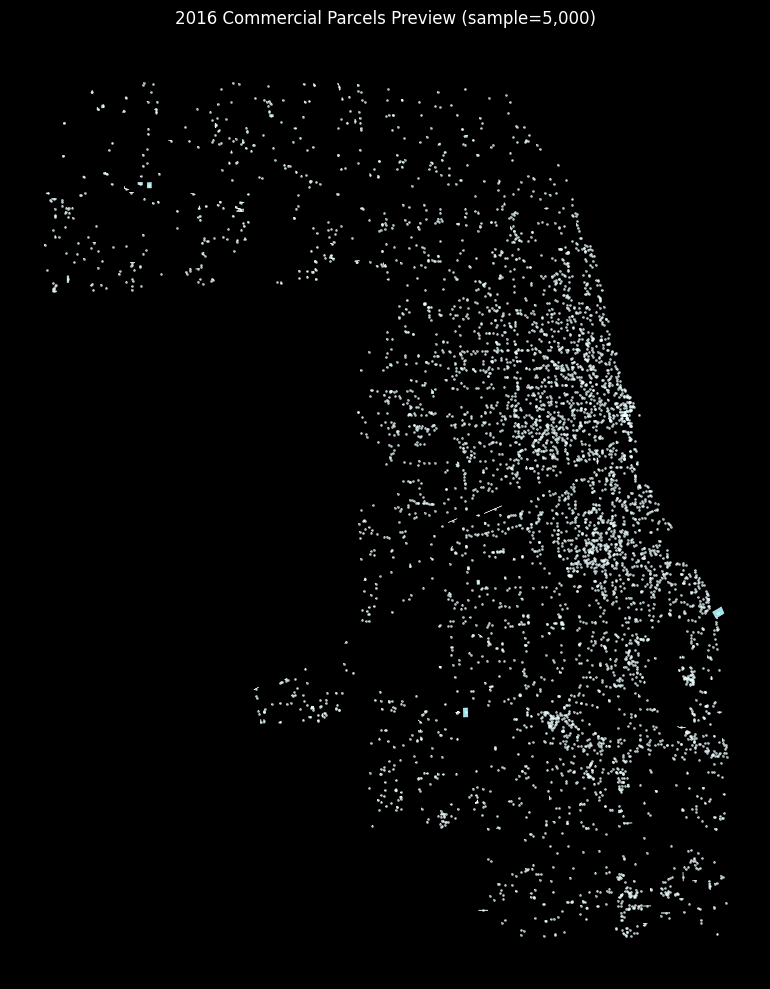

In [6]:
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt

# Optional preview map (dark style + ultra-bright commercial polygons)
out_dir = Path("outputs") / "assessed_values"
commercial_gpkg = out_dir / "parcels_2016_commercial.gpkg"

if commercial_gpkg.exists():
    commercial_parcels_plot = gpd.read_file(commercial_gpkg)
    print(f"Loaded existing data: {commercial_gpkg}")
elif "commercial_parcels_2016" in globals():
    commercial_parcels_plot = commercial_parcels_2016.copy()
    print("Using in-memory variable: commercial_parcels_2016")
else:
    raise FileNotFoundError(
        f"Cannot find {commercial_gpkg}. Run Step 2 once to generate it."
    )

preview_n = min(5000, len(commercial_parcels_plot))
preview_plot = (
    commercial_parcels_plot.sample(preview_n, random_state=42)
    if len(commercial_parcels_plot) > preview_n
    else commercial_parcels_plot
)

fig, ax = plt.subplots(figsize=(10, 10), facecolor="#000000")
ax.set_facecolor("#000000")

# Very dim outlines for structure
preview_plot.boundary.plot(
    ax=ax,
    linewidth=0.10,
    color="#1f2937",
    alpha=0.20,
    zorder=1,
)

# Bright polygon fill
preview_plot.plot(
    ax=ax,
    linewidth=0.30,
    edgecolor="#ffffff",
    facecolor="#a5f3fc",
    alpha=0.95,
    zorder=2,
)

# Extra bright point-cloud overlay to make tiny parcels visible
centroids = preview_plot.geometry.centroid
ax.scatter(
    centroids.x,
    centroids.y,
    s=3.5,
    c="#ecfeff",
    alpha=0.75,
    linewidths=0,
    zorder=3,
)

ax.set_title(
    f"2016 Commercial Parcels Preview (sample={preview_n:,})",
    color="#ffffff",
    pad=12,
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Step 3 - Business License x Parcel(2016)

Business License OData: https://data.cityofchicago.org/api/odata/v4/r5kz-chrr?$format=json

In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import pyarrow as pa
import pyarrow.parquet as pq

# -------------------------
# Step 3 - Business License x Parcel(2016 Commercial)
# -------------------------

license_path = Path("Business_Licenses_20260424.csv")
parcel_out_dir = Path("outputs") / "assessed_values"
license_out_dir = Path("outputs") / "license_parquet"
license_out_dir.mkdir(parents=True, exist_ok=True)

commercial_parcel_gpkg = parcel_out_dir / "parcels_2016_commercial.gpkg"
licenses_2016_all_parquet = license_out_dir / "licenses_2016_all.parquet"
licenses_2016_matched_parquet = license_out_dir / "licenses_2016_matched_commercial.parquet"
licenses_2016_all_csv = license_out_dir / "licenses_2016_all.csv"
licenses_2016_matched_csv = license_out_dir / "licenses_2016_matched_commercial.csv"
licenses_2016_stats_csv = license_out_dir / "licenses_2016_match_summary.csv"

if "commercial_parcels_2016" in globals():
    commercial_parcels_for_join = commercial_parcels_2016.copy()
else:
    commercial_parcels_for_join = gpd.read_file(commercial_parcel_gpkg)

parcel_keep_cols = [
    col for col in ["PIN10", "pin10_key", "class_count", "class_list", "PARCELTYPE", "SHAPE_STAr", "geometry"]
    if col in commercial_parcels_for_join.columns
]
commercial_parcels_for_join = commercial_parcels_for_join[parcel_keep_cols].copy()

licenses = pd.read_csv(
    license_path,
    dtype=str,
    low_memory=False,
    keep_default_na=False,
    na_values=["", "NA", "N/A", "NULL"],
)

for col in ["LICENSE TERM START DATE", "LICENSE TERM EXPIRATION DATE", "DATE ISSUED"]:
    licenses[col] = pd.to_datetime(licenses[col], errors="coerce")

for col in ["LATITUDE", "LONGITUDE"]:
    licenses[col] = pd.to_numeric(licenses[col], errors="coerce")

analysis_start = pd.Timestamp("2016-01-01")
analysis_end = pd.Timestamp("2016-12-31")
today = pd.Timestamp.today().normalize()

licenses["start_eff"] = licenses["LICENSE TERM START DATE"].fillna(licenses["DATE ISSUED"])

licenses["is_valid_in_2016"] = (
    licenses["start_eff"].notna()
    & (licenses["start_eff"] <= analysis_end)
    & (licenses["LICENSE TERM EXPIRATION DATE"].isna() | (licenses["LICENSE TERM EXPIRATION DATE"] >= analysis_start))
)
licenses["active_now"] = (
    licenses["LICENSE TERM EXPIRATION DATE"].isna()
    | (licenses["LICENSE TERM EXPIRATION DATE"] >= today)
)
licenses["license_group"] = licenses["active_now"].map({True: "active_now", False: "historic_now"})

licenses_2016 = licenses.loc[licenses["is_valid_in_2016"]].copy()
licenses_2016_geo = licenses_2016.loc[licenses_2016["LATITUDE"].notna() & licenses_2016["LONGITUDE"].notna()].copy()

licenses_2016_points = gpd.GeoDataFrame(
    licenses_2016_geo,
    geometry=gpd.points_from_xy(licenses_2016_geo["LONGITUDE"], licenses_2016_geo["LATITUDE"]),
    crs="EPSG:4326",
)
licenses_2016_points = licenses_2016_points.to_crs(commercial_parcels_for_join.crs)

licenses_2016_matched = gpd.sjoin(
    licenses_2016_points,
    commercial_parcels_for_join,
    how="inner",
    predicate="within",
).drop(columns=[col for col in ["index_right"] if col in licenses_2016_points.columns or True], errors="ignore")

summary_rows = [
    {"metric": "total_full_license_rows", "value": int(len(licenses))},
    {"metric": "valid_in_2016_rows", "value": int(len(licenses_2016))},
    {"metric": "valid_in_2016_with_latlon_rows", "value": int(len(licenses_2016_geo))},
    {"metric": "matched_to_commercial_parcel_rows", "value": int(len(licenses_2016_matched))},
    {"metric": "match_rate_over_valid_with_latlon", "value": round(len(licenses_2016_matched) / max(len(licenses_2016_geo), 1), 6)},
    {"metric": "unique_matched_license_ids", "value": int(licenses_2016_matched["LICENSE ID"].nunique()) if "LICENSE ID" in licenses_2016_matched.columns else int(len(licenses_2016_matched))},
    {"metric": "unique_matched_pin10", "value": int(licenses_2016_matched["PIN10"].nunique()) if "PIN10" in licenses_2016_matched.columns else -1},
]
summary_df = pd.DataFrame(summary_rows)

license_group_stats = (
    licenses_2016_matched["license_group"]
    .value_counts(dropna=False)
    .rename_axis("license_group")
    .reset_index(name="rows")
)
license_group_stats["pct"] = (license_group_stats["rows"] / max(len(licenses_2016_matched), 1) * 100).round(4)

print("=== Step 3 Stats: Business Licenses x 2016 Commercial Parcels ===")
for row in summary_rows:
    metric = row["metric"]
    value = row["value"]
    if isinstance(value, float) and value <= 1:
        print(f"{metric}: {value:.2%}")
    else:
        print(f"{metric}: {value:,}" if isinstance(value, int) else f"{metric}: {value}")

print("\n=== Matched license group distribution ===")
display(license_group_stats)

preview_cols = [
    col for col in [
        "LICENSE ID", "LEGAL NAME", "DOING BUSINESS AS NAME", "LICENSE DESCRIPTION",
        "ADDRESS", "LICENSE TERM START DATE", "LICENSE TERM EXPIRATION DATE",
        "LICENSE STATUS", "license_group", "PIN10", "class_count", "class_list", "PARCELTYPE"
    ]
    if col in licenses_2016_matched.columns
]
print("\n=== Preview of matched 2016 licenses ===")
display(licenses_2016_matched[preview_cols].head(20))

licenses_2016_plain = pd.DataFrame(licenses_2016)
licenses_2016_matched_plain = pd.DataFrame(licenses_2016_matched.drop(columns="geometry", errors="ignore"))

licenses_2016_plain.to_csv(licenses_2016_all_csv, index=False, encoding="utf-8-sig")
licenses_2016_matched_plain.to_csv(licenses_2016_matched_csv, index=False, encoding="utf-8-sig")
summary_export = summary_df.copy()
summary_export.to_csv(licenses_2016_stats_csv, index=False, encoding="utf-8-sig")

pq.write_table(pa.Table.from_pandas(licenses_2016_plain, preserve_index=False), licenses_2016_all_parquet)
pq.write_table(pa.Table.from_pandas(licenses_2016_matched_plain, preserve_index=False), licenses_2016_matched_parquet)

print("\nSaved outputs:")
print(licenses_2016_all_parquet)
print(licenses_2016_matched_parquet)
print(licenses_2016_all_csv)
print(licenses_2016_matched_csv)
print(licenses_2016_stats_csv)

# Optional dark-style map for matched license addresses
if len(licenses_2016_matched) > 0:
    point_preview_n = min(20000, len(licenses_2016_matched))
    points_preview = licenses_2016_matched.sample(point_preview_n, random_state=42) if len(licenses_2016_matched) > point_preview_n else licenses_2016_matched

    fig, ax = plt.subplots(figsize=(10, 10), facecolor="#020617")
    ax.set_facecolor("#020617")

    # Dim parcel outlines as context
    commercial_parcels_for_join.boundary.plot(
        ax=ax,
        linewidth=0.15,
        color="#334155",
        alpha=0.35,
        zorder=1,
)

    # Bright address points for visibility on dark background
    points_preview.plot(
        ax=ax,
        markersize=3.2,
        color="#fde047",
        alpha=0.9,
        zorder=2,
)

    ax.set_title(
        f"2016 Matched License Addresses (sample={point_preview_n:,})",
        color="#f8fafc",
        pad=12,
)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
else:
    print("No matched license addresses to plot.")

=== Step 3 Stats: Business Licenses x 2016 Commercial Parcels ===
total_full_license_rows: 1,194,424
valid_in_2016_rows: 100,613
valid_in_2016_with_latlon_rows: 92,955
matched_to_commercial_parcel_rows: 49,496
match_rate_over_valid_with_latlon: 53.25%
unique_matched_license_ids: 40,456
unique_matched_pin10: 13,294

=== Matched license group distribution ===


,license_group,rows,pct
0,historic_now,49483,99.9737
1,active_now,13,0.0263



=== Preview of matched 2016 licenses ===


,LICENSE ID,LEGAL NAME,DOING BUSINESS AS NAME,LICENSE DESCRIPTION,ADDRESS,LICENSE TERM START DATE,LICENSE TERM EXPIRATION DATE,LICENSE STATUS,license_group,PIN10,class_count,class_list,PARCELTYPE
9374,2430618,JORGE M. GARCIA,WHEELS ON ELSTON,Motor Vehicle Services License,4433 N ELSTON AVE,2015-12-16,2017-12-15,AAI,historic_now,1315237013,1,212,1
10781,2426541,HALO SALON FOR MEN BUCKTOWN,HALO SALON FOR MEN BT,Limited Business License,1655 N DAMEN AVE 1,2015-11-16,2017-11-15,AAI,historic_now,1431424052,2,517|522,1
14710,2321518,CHARIYA SOPANARAT,ROONG PETCH THAI RESTAURANT,Retail Food Establishment,1828 W MONTROSE AVE,2014-06-16,2016-06-15,AAI,historic_now,1418220009,1,517,1
28027,2472329,ELVIA JAIME,TIFFANY'S FLOWERS & GIFTS,Limited Business License,3645 W 25TH ST 1ST,2016-08-16,2018-08-15,AAI,historic_now,1626124018,1,212,1
62493,2468789,"ZETA ENTERPRISES, INC.",HONORARY CHICAGO,Limited Business License,222 W MERCHANDISE MART PLZ 12TH 1212,2016-07-16,2018-07-15,AAI,historic_now,1709403002,1,591,1
74425,2387042,AMERICAN OSTEOPATHIC ASSOCIATION,AMERICAN OSTEOPATHIC ASSOC.,Limited Business License,142 E ONTARIO ST 2,2015-05-16,2017-05-15,AAI,historic_now,1710114006,3,100|591|592,1
74777,2495103,"BAIT FAST FOOD, INC.",CRAZY PHILLY FISH & CHICKEN,Retail Food Establishment,5448 W HARRISON ST,2016-12-16,2018-12-15,AAI,historic_now,1616121006,1,517,1
103895,2441537,CHICAGO SUNSHINE INC.,CHICAGO SUNSHINE INC.,Tobacco,3206-3208 N CENTRAL AVE 1ST,2016-02-16,2018-02-15,AAI,historic_now,1320433015,1,592,1
105081,2474278,LARRY YOUNG,TOO NICE TATTOOS,Regulated Business License,1714 W 79TH ST 1,2016-08-16,2018-08-15,AAI,historic_now,2030433034,1,517,1
105108,2486274,CONDOWASH LLC,CONDOWASH,Regulated Business License,1235 S PRAIRIE AVE 22ND 2209,2016-10-16,2018-10-15,AAI,historic_now,1722110136,1,597,1



Saved outputs:
outputs\license_parquet\licenses_2016_all.parquet
outputs\license_parquet\licenses_2016_matched_commercial.parquet
outputs\license_parquet\licenses_2016_all.csv
outputs\license_parquet\licenses_2016_matched_commercial.csv
outputs\license_parquet\licenses_2016_match_summary.csv


# Process All in